<a href="https://colab.research.google.com/github/HariniDD07/HDD-project/blob/main/HDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("student_performance.csv")
df

,Student_Id,Name,Class,Tamil,English,Maths,Sciene,Social
0,101,Harini,CSE-A,85,78,92,88,81
1,102,Priya,CSE-A,65,70,60,72,68
2,103,Kavin,CSE-A,95,90,98,96,94
3,104,Rahul,CSE-B,40,45,38,50,42
4,105,Meena,CSE-B,75,82,79,80,77
5,106,Arjun,CSE-C,55,60,58,62,57
6,107,Divya,CSE-C,89,91,87,90,92


In [ ]:
# 1. Calculate Total Marks and Average
subject_columns = ['Tamil', 'English', 'Maths', 'Sciene', 'Social']
df['Total'] = df[subject_columns].sum(axis=1)
df['Average'] = df[subject_columns].mean(axis=1)

# 2. Determine Pass/Fail Status (Passing mark is 40 in all subjects)
df['Status'] = df[subject_columns].apply(lambda row: 'Pass' if all(x >= 40 for x in row) else 'Fail', axis=1)

# 3. Assign Grades based on Average
def assign_grade(avg):
    if avg >= 90: return 'O (Outstanding)'
    elif avg >= 80: return 'A+'
    elif avg >= 70: return 'A'
    elif avg >= 60: return 'B+'
    elif avg >= 50: return 'B'
    elif avg >= 40: return 'C'
    else: return 'F (Fail)'

df['Grade'] = df['Average'].apply(assign_grade)

# Display the updated DataFrame
print("--- Student Performance Summary ---")
df

--- Student Performance Summary ---


,Student_Id,Name,Class,Tamil,English,Maths,Sciene,Social,Total,Average,Status,Grade
0,101,Harini,CSE-A,85,78,92,88,81,424,84.8,Pass,A+
1,102,Priya,CSE-A,65,70,60,72,68,335,67.0,Pass,B+
2,103,Kavin,CSE-A,95,90,98,96,94,473,94.6,Pass,O (Outstanding)
3,104,Rahul,CSE-B,40,45,38,50,42,215,43.0,Fail,C
4,105,Meena,CSE-B,75,82,79,80,77,393,78.6,Pass,A
5,106,Arjun,CSE-C,55,60,58,62,57,292,58.4,Pass,B
6,107,Divya,CSE-C,89,91,87,90,92,449,89.8,Pass,A+


In [ ]:
print("=== 1. OVERALL CLASS TOPPER ===")
topper = df[df['Status'] == 'Pass'].sort_values(by='Total', ascending=False).iloc[0]
print(f"Topper Name: {topper['Name']} | Class: {topper['Class']} | Total Marks: {topper['Total']} | Average: {topper['Average']:.2f}\n")

print("=== 2. STUDENTS REQUIRING ATTENTION (FAILED IN 1 OR MORE SUBJECTS) ===")
weak_students = df[df['Status'] == 'Fail'][['Student_Id', 'Name', 'Class', 'Status']]
if not weak_students.empty:
    print(weak_students)
else:
    print("All students passed!")

print("\n=== 3. SUBJECT-WISE AVERAGE PERFORMANCE ===")
subject_stats = df[subject_columns].mean()
print(subject_stats)

=== 1. OVERALL CLASS TOPPER ===
Topper Name: Kavin | Class: CSE-A | Total Marks: 473 | Average: 94.60

=== 2. STUDENTS REQUIRING ATTENTION (FAILED IN 1 OR MORE SUBJECTS) ===
   Student_Id   Name  Class Status
3         104  Rahul  CSE-B   Fail

=== 3. SUBJECT-WISE AVERAGE PERFORMANCE ===
Tamil      72.000000
English    73.714286
Maths      73.142857
Sciene     76.857143
Social     73.000000
dtype: float64


/tmp/ipykernel_577/91879381.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subject_means.index, y=subject_means.values, palette='viridis')


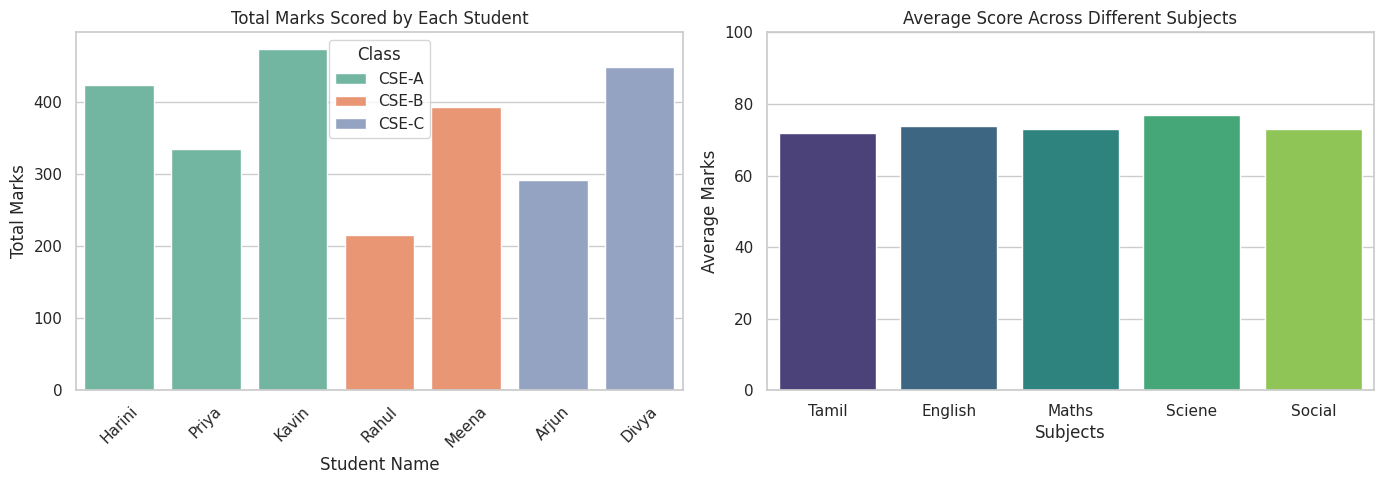

In [ ]:
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# Chart 1: Total Marks by Student
plt.subplot(1, 2, 1)
sns.barplot(x='Name', y='Total', hue='Class', data=df, palette='Set2')
plt.title('Total Marks Scored by Each Student')
plt.xlabel('Student Name')
plt.ylabel('Total Marks')
plt.xticks(rotation=45)

# Chart 2: Subject-Wise Performance Average
plt.subplot(1, 2, 2)
subject_means = df[subject_columns].mean()
sns.barplot(x=subject_means.index, y=subject_means.values, palette='viridis')
plt.title('Average Score Across Different Subjects')
plt.xlabel('Subjects')
plt.ylabel('Average Marks')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
print("=== CLASS-WISE AVERAGE PERFORMANCE COMPARISON ===")
class_comparison = df.groupby('Class')[['Total', 'Average']].mean()
print(class_comparison)

print("\n=== CLASS-WISE PASS/FAIL COUNT ===")
class_status = pd.crosstab(df['Class'], df['Status'])
print(class_status)

=== CLASS-WISE AVERAGE PERFORMANCE COMPARISON ===
            Total    Average
Class                       
CSE-A  410.666667  82.133333
CSE-B  304.000000  60.800000
CSE-C  370.500000  74.100000

=== CLASS-WISE PASS/FAIL COUNT ===
Status  Fail  Pass
Class             
CSE-A      0     3
CSE-B      1     1
CSE-C      0     2
